<a href="https://colab.research.google.com/github/sdey55018/AIML_LAB/blob/main/Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install networkx matplotlib

Graph (Adjacency List):
 A -> ['B', 'C']
 B -> ['A', 'D', 'E']
 C -> ['A', 'F']
 D -> ['B']
 E -> ['B']
 F -> ['C']

BFS Traversal starting from 'A': A -> B -> C -> D -> E -> F
DFS Traversal starting from 'A': A -> B -> D -> E -> C -> F


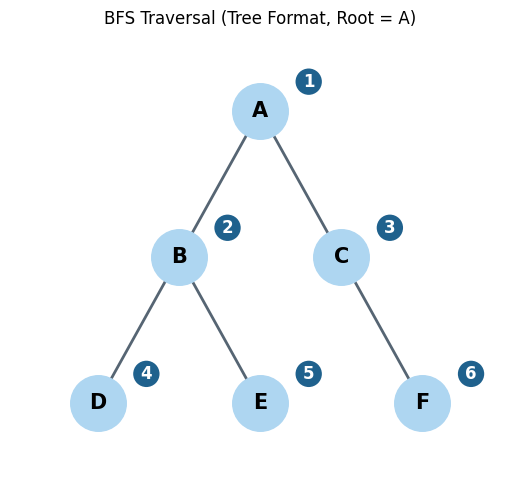

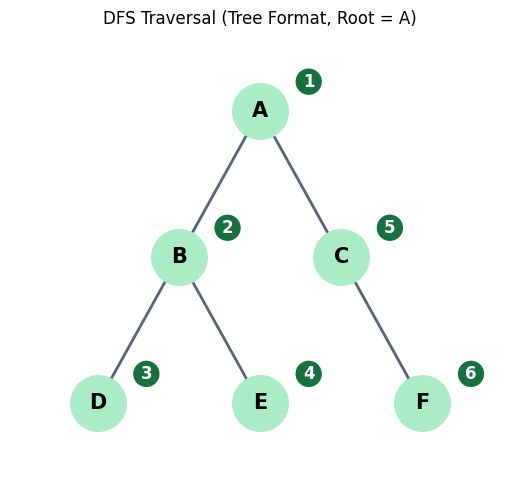

In [6]:
!pip install networkx matplotlib
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
# Step 1: Create the graph using a dictionary (adjacency list)
# This graph is shaped like a tree, with 'A' as the root node.
graph = {
'A': ['B', 'C'],
'B': ['A', 'D', 'E'],
'C': ['A', 'F'],
'D': ['B'],
'E': ['B'],
'F': ['C']
}
# Step 2: BFS function
def bfs(graph, start):
    visited = set()
    order = []
    queue = deque([start])
    visited.add(start)
    while queue:
        node = queue.popleft()
        order.append(node)
        for neighbour in graph[node]:
            if neighbour not in visited:
              visited.add(neighbour)
              queue.append(neighbour)
    return order
# Step 3: DFS function (using recursion)
def dfs(graph, start, visited=None, order=None):
    if visited is None:
        visited = set()
        order = []
    visited.add(start)
    order.append(start)
    for neighbour in graph[start]:
        if neighbour not in visited:
            dfs(graph, neighbour, visited, order)
    return order
# Step 4: Run BFS and DFS starting from node 'A'
bfs_result = bfs(graph, 'A')
dfs_result = dfs(graph, 'A')
print("Graph (Adjacency List):")
for node in graph:
    print(f" {node} -> {graph[node]}")
print("\nBFS Traversal starting from 'A':", " -> ".join(bfs_result))
print("DFS Traversal starting from 'A':", " -> ".join(dfs_result))
# Step 5: Draw the SAME tree structure twice - once showing the BFS visit
# order, and once showing the DFS visit order. Both use the same tree
# layout (root at top, children below); only the order numbers/colours differ.
G = nx.Graph()
for node, neighbours in graph.items():
    for n in neighbours:
        G.add_edge(node, n)
def tree_positions(graph, root):
    """Compute (x, y) positions so the tree is drawn level by level,
    with the root at the top."""
    levels = {} # node -> level number (0 = root)
    level_nodes = {} # level number -> list of nodes at that level
    queue = deque([root])
    levels[root] = 0
    while queue:
        node = queue.popleft()
        lvl = levels[node]
        level_nodes.setdefault(lvl, []).append(node)
        for neighbour in graph[node]:
            if neighbour not in levels:
                levels[neighbour] = lvl + 1
                queue.append(neighbour)
    pos = {}
    for lvl, nodes in level_nodes.items():
        count = len(nodes)
        for i, node in enumerate(nodes):
            x = i - (count - 1) / 2 # centre the nodes of this level
            pos[node] = (x, -lvl) # negative so root (level 0) is at the top
    return pos
pos = tree_positions(graph, 'A')
def draw_traversal_tree(order, title, node_color, badge_color):
    """Draw the tree and mark each node with a small circular badge
    showing the order in which it was visited (1, 2, 3, ...)."""
    order_number = {node: i + 1 for i, node in enumerate(order)}
    plt.figure(figsize=(5, 4.5))
    nx.draw(G, pos, with_labels=True, node_color=node_color, node_size=1600,
            font_size=15, font_weight='bold', edge_color='#566573', width=2)
    for node, (x, y) in pos.items():
        plt.text(x + 0.30, y + 0.20, str(order_number[node]),
                 fontsize=12, fontweight='bold', color='white',
                 ha='center', va='center',
                 bbox=dict(boxstyle='circle,pad=0.25', facecolor=badge_color,
                           edgecolor='none'))
    plt.title(title)
    plt.margins(0.2)
    plt.show()
# BFS tree diagram: node order numbers follow the BFS (level-by-level) sequence
draw_traversal_tree(bfs_result, "BFS Traversal (Tree Format, Root = A)",
                    node_color='#AED6F1', badge_color='#1F618D')
# DFS tree diagram: node order numbers follow the DFS (deep-first) sequence
draw_traversal_tree(dfs_result, "DFS Traversal (Tree Format, Root = A)",
                    node_color='#ABEBC6', badge_color='#196F3D')